### Importación de datos



In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



## Análisis de Facturación

Dado que cada registro en el conjunto de datos representa una transacción individual y única, el valor contenido en la columna **`precio`** corresponde
al ingreso generado por una unidad vendida. Por otro lado, el **`costo`** asociado a cada transacción representa un egreso asumido por la tienda y, por tanto, no se considera en el cálculo directo de la facturación.

Bajo esta definición, la **facturación total** de la tienda se obtiene mediante la suma agregada de los valores en la columna **`precio`**, es decir:

$$
\text{Facturación Total} = \sum_{i=1}^{n} \text{precio}_i
$$

donde \( n \) es el número total de registros (ventas) en el conjunto de datos.

In [ ]:
facturacion_total_tienda = tienda['Precio'].sum() / 100
print(f"Facturación total (Tienda 1): ${facturacion_total_tienda:,.2f}\n")

facturacion_total_tienda2 = tienda2['Precio'].sum() / 100
print(f"Facturación total (Tienda 2): ${facturacion_total_tienda2:,.2f}\n")

facturacion_total_tienda3 = tienda3['Precio'].sum() / 100
print(f"Facturación total (Tienda 3): ${facturacion_total_tienda3:,.2f}\n")

facturacion_total_tienda4 = tienda4['Precio'].sum() / 100
print(f"Facturación total (Tienda 4): ${facturacion_total_tienda4:,.2f}\n")


Facturación total (Tienda 1): $11,508,804.00

Facturación total (Tienda 2): $11,163,435.00

Facturación total (Tienda 3): $10,980,196.00

Facturación total (Tienda 4): $10,383,757.00



In [59]:
#@title 2. Ventas por categoría
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

for nombre, df in tiendas.items():
    print(f"--- Resultados para {nombre} ---")


    ventas_por_categoria = (
        df.groupby("Categoría del Producto")
        .size()
        .reset_index(name="Total Ventas")
        .sort_values(by="Total Ventas", ascending=False)
        .reset_index(drop=True)
    )

    categoria_mas_vendida = ventas_por_categoria.iloc[0]["Categoría del Producto"]

    styled_table = (
        ventas_por_categoria.style
        .hide(axis="index")
        .set_caption(f"Ventas por categoría en {nombre} | Categoría más vendida: {categoria_mas_vendida}")
        .format({"Total Ventas": "{:,.0f}"})
    )

    display(styled_table)
    print("\n" + "="*40 + "\n")




--- Resultados para Tienda 1 ---


Categoría del Producto,Total Ventas
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171




--- Resultados para Tienda 2 ---


Categoría del Producto,Total Ventas
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181




--- Resultados para Tienda 3 ---


Categoría del Producto,Total Ventas
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Artículos para el hogar,177
Instrumentos musicales,177




--- Resultados para Tienda 4 ---


Categoría del Producto,Total Ventas
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


In [58]:
#@title 3. Calificación promedio de la tienda
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}
medias = []

for nombre, df in tiendas.items():
    media = df['Calificación'].mean()
    medias.append({
        "Tienda": nombre,
        "Media de Calificación": media
    })

df_medias = pd.DataFrame(medias).round(2)
styled_table = (
    df_medias.style
    .hide(axis="index")
    .set_caption("MEDIA DE CALIFICACIONES POR TIENDA")
    .background_gradient(cmap='Blues', subset=["Media de Calificación"])
    .format({
        "Media de Calificación": "{:.2f} ★"
    })
)

display(styled_table)

Tienda,Media de Calificación
Tienda 1,3.98 ★
Tienda 2,4.04 ★
Tienda 3,4.05 ★
Tienda 4,4.00 ★


In [57]:
# @title 4. Productos más y menos vendidos
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

resultados = []

for nombre, df in tiendas.items():
    ventas_producto = df['Producto'].value_counts()


    producto_mas_vendido = ventas_producto.index[0]
    total_mas_vendido = ventas_producto.iloc[0]


    producto_menos_vendido = ventas_producto.index[-1]
    total_menos_vendido = ventas_producto.iloc[-1]

    resultados.append({
        "Tienda": nombre,
        "Producto Más Vendido": producto_mas_vendido,
        "Ventas (Más Vendido)": total_mas_vendido,
        "Producto Menos Vendido": producto_menos_vendido,
        "Ventas (Menos Vendido)": total_menos_vendido
    })

df_resultados = pd.DataFrame(resultados)
styled_table = (
    df_resultados.style
    .hide(axis="index")
    .set_caption("PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA")
    .background_gradient(cmap='Greens', subset=["Ventas (Más Vendido)"])
    .background_gradient(cmap='Reds', subset=["Ventas (Menos Vendido)"])
    .format({
        "Ventas (Más Vendido)": "{:,.0f}",
        "Ventas (Menos Vendido)": "{:,.0f}"
    })
)

display(styled_table)

Tienda,Producto Más Vendido,Ventas (Más Vendido),Producto Menos Vendido,Ventas (Menos Vendido)
Tienda 1,Microondas,60,Celular ABXY,33
Tienda 2,Iniciando en programación,65,Juego de mesa,32
Tienda 3,Kit de bancas,57,Bloques de construcción,35
Tienda 4,Cama box,62,Guitarra eléctrica,33


In [56]:
# @title 5. Envío promedio por tienda

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

resultados = []

for nombre, df in tiendas.items():
    promedio_envio = df['Costo de envío'].mean()
    total_envios = df['Costo de envío'].count()
    total_gastado = df['Costo de envío'].sum()

    resultados.append({
        "Tienda": nombre,
        "Promedio Costo de Envío": promedio_envio,
        "Total Envíos": total_envios,
        "Total Gastado en Envíos": total_gastado
    })

df_promedios = pd.DataFrame(resultados).round(2)
styled_table = (
    df_promedios.style
    .hide(axis="index")
    .set_caption("PROMEDIO DE COSTO DE ENVÍO POR TIENDA")
    .background_gradient(cmap='YlOrRd', subset=["Promedio Costo de Envío"])
    .format({
        "Promedio Costo de Envío": "${:,.2f}",
        "Total Gastado en Envíos": "${:,.2f}"
    })
)

display(styled_table)

Tienda,Promedio Costo de Envío,Total Envíos,Total Gastado en Envíos
Tienda 1,"$26,018.61",2359,"$61,377,900.00"
Tienda 2,"$25,216.24",2359,"$59,485,100.00"
Tienda 3,"$24,805.68",2359,"$58,516,600.00"
Tienda 4,"$23,459.46",2358,"$55,317,400.00"


#Visualización#

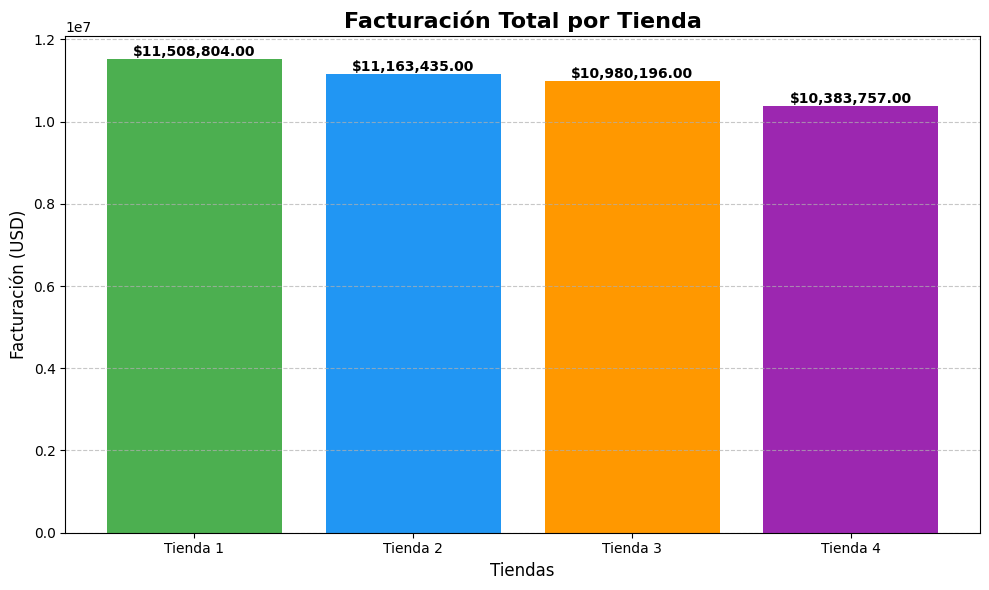

In [26]:
# @title Ventas Totales por Tienda

facturaciones = [
    facturacion_total_tienda,
    facturacion_total_tienda2,
    facturacion_total_tienda3,
    facturacion_total_tienda4
]
nombres_tiendas = list(tiendas.keys())

plt.figure(figsize=(10, 6))
barras = plt.bar(nombres_tiendas, facturaciones, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])

plt.title('Facturación Total por Tienda', fontsize=16, fontweight='bold')
plt.ylabel('Facturación (USD)', fontsize=12)
plt.xlabel('Tiendas', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)


for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 100, f"${altura:,.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

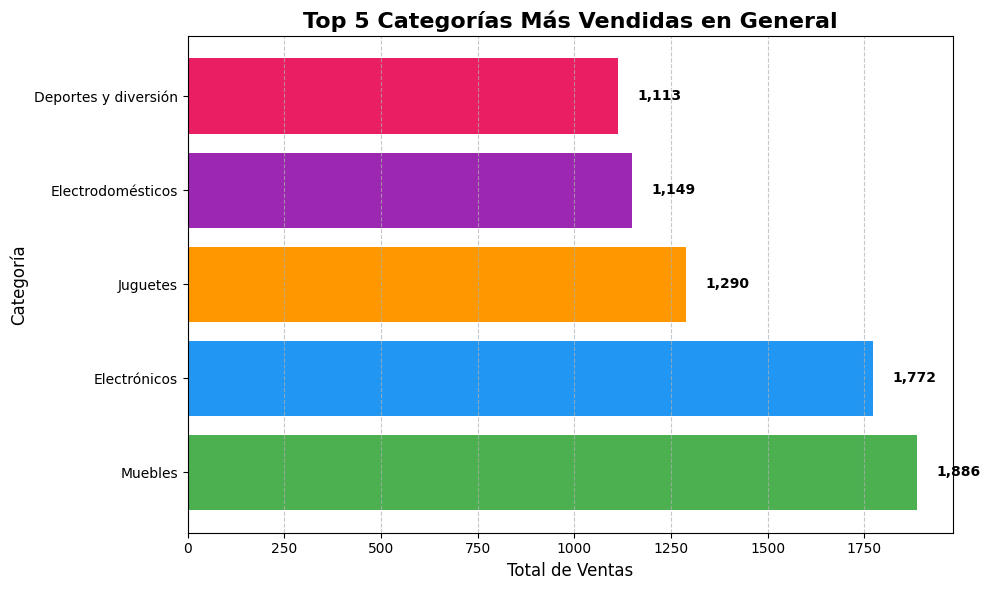

In [55]:
#@title Categorias mas vendidas
ventas_combinadas = pd.concat([tienda, tienda2, tienda3, tienda4])

ventas_por_categoria = (
    ventas_combinadas.groupby("Categoría del Producto")
    .size()
    .reset_index(name="Total Ventas")
    .sort_values(by="Total Ventas", ascending=False)
)

top5_categorias = ventas_por_categoria.head(5)

plt.figure(figsize=(10, 6))
barras = plt.barh(
    top5_categorias["Categoría del Producto"],
    top5_categorias["Total Ventas"],
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#E91E63']
)

plt.title("Top 5 Categorías Más Vendidas en General", fontsize=16, fontweight='bold')
plt.xlabel("Total de Ventas", fontsize=12)
plt.ylabel("Categoría", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for barra in barras:
    ancho = barra.get_width()
    plt.text(
        ancho + 50,
        barra.get_y() + barra.get_height() / 2,
        f"{ancho:,.0f}",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

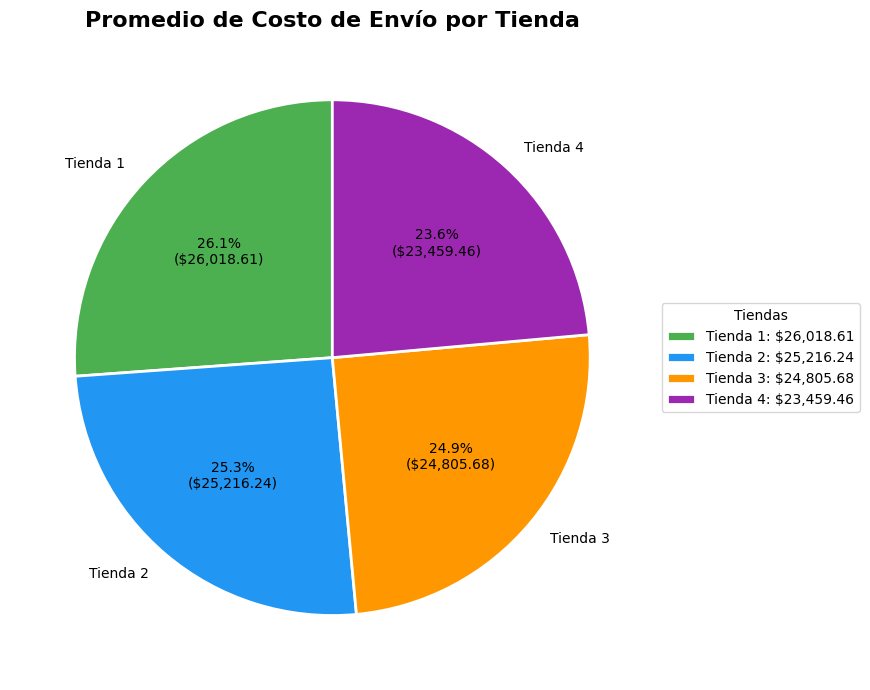

In [53]:
#@title Costo promedio de envio por tienda

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

promedios_envio = {}
for nombre, df in tiendas.items():
    promedio = df['Costo de envío'].mean()
    promedios_envio[nombre] = promedio

df_promedios = pd.DataFrame.from_dict(promedios_envio, orient='index', columns=["Promedio Costo de Envío"])

plt.figure(figsize=(10, 7))
colores = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

explode = [0, 0, 0, 0]


plt.pie(
    df_promedios["Promedio Costo de Envío"],
    labels=df_promedios.index,
    colors=colores,
    explode=explode,
    autopct=lambda p: f'{p:.1f}%\n(${p * sum(promedios_envio.values())/100:,.2f})',  # Muestra porcentaje y valor absoluto
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title("Promedio de Costo de Envío por Tienda", fontsize=16, fontweight='bold')
plt.legend(
    title="Tiendas",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    labels=[f"{label}: ${value:,.2f}" for label, value in zip(df_promedios.index, df_promedios["Promedio Costo de Envío"])]
)

plt.tight_layout()
plt.show()

#Analisis